# 06 — Sistema de Recomendação de Produtos
## LH Nautical | Personalização e Cross-sell

**Objetivo:** Identificar oportunidades de venda cruzada e personalização
através de análise de padrões de compra conjunta.

**Abordagens implementadas:**

| Abordagem             | Caso de uso                                    |
|-----------------------|------------------------------------------------|
| Popularidade global   | Novos visitantes (cold start)                  |
| Produtos relacionados | "Voce tambem pode gostar" na pagina do produto |
| Analise de cesta (MBA)| Kits promocionais, cross-sell no caixa         |

> **Contexto:** Com 49 clientes e alta recorrência (B2B), a análise de cesta
> tem suporte robusto — cada cliente compra dezenas de produtos diferentes.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.recommendation.recommender import (
    recomendacao_por_popularidade, produtos_relacionados, analise_cesta_compras
)

plt.style.use('seaborn-v0_8-whitegrid')
AZUL_LH    = '#1565C0'
VERDE_LH   = '#2E7D32'
LARANJA_LH = '#E65100'

fato     = pd.read_parquet('../data/gold/fato_vendas.parquet')
dim_prod = pd.read_parquet('../data/gold/dim_produtos.parquet')

print(f'Dados carregados: {len(fato):,} transacoes | {fato["id_produto"].nunique()} produtos | {fato["id_cliente"].nunique()} clientes')

Dados carregados: 9,895 transacoes | 150 produtos | 49 clientes


---
## 1. Recomendação por Popularidade

Usada na **homepage** e para **novos visitantes** sem histórico de compras.

In [2]:
pop_receita = recomendacao_por_popularidade(fato, n=10, por='receita')
pop_volume  = recomendacao_por_popularidade(fato, n=10, por='volume')

# Enriquecer com nomes
pop_receita = pop_receita.merge(dim_prod[['id_produto','nome_produto','categoria']], on='id_produto')
pop_volume  = pop_volume.merge(dim_prod[['id_produto','nome_produto','categoria']], on='id_produto')

print('Top 10 por RECEITA (recomendado para homepage):')
display(pop_receita[['rank','nome_produto','categoria','receita_total','clientes_unicos']].head(8))

Top 10 por RECEITA (recomendado para homepage):


,rank,nome_produto,categoria,receita_total,clientes_unicos
0,1,Motor Diesel Honda Aero 205HP,Propulsão,83539339.40,37
1,2,Motor Elétrico Torqeedo Pulse 300HP,Propulsão,81567066.65,36
2,3,Motor de Popa Torqeedo Core Hydra Flux 162HP,Propulsão,69554254.80,37
3,4,Motor Elétrico Torqeedo Ion Orca Vox 186HP,Propulsão,68817185.90,36
4,5,Motor de Popa Volvo Maré 69HP,Propulsão,67332086.05,38
5,6,Motor Elétrico Tohatsu Zenith Oceanic 113HP,Propulsão,66829268.70,34
6,7,Motor de Popa Yamaha Evo Dash 155HP,Propulsão,65859716.10,32
7,8,Motor Elétrico Torqeedo Barracuda Magnum Helix...,Propulsão,64195127.60,36


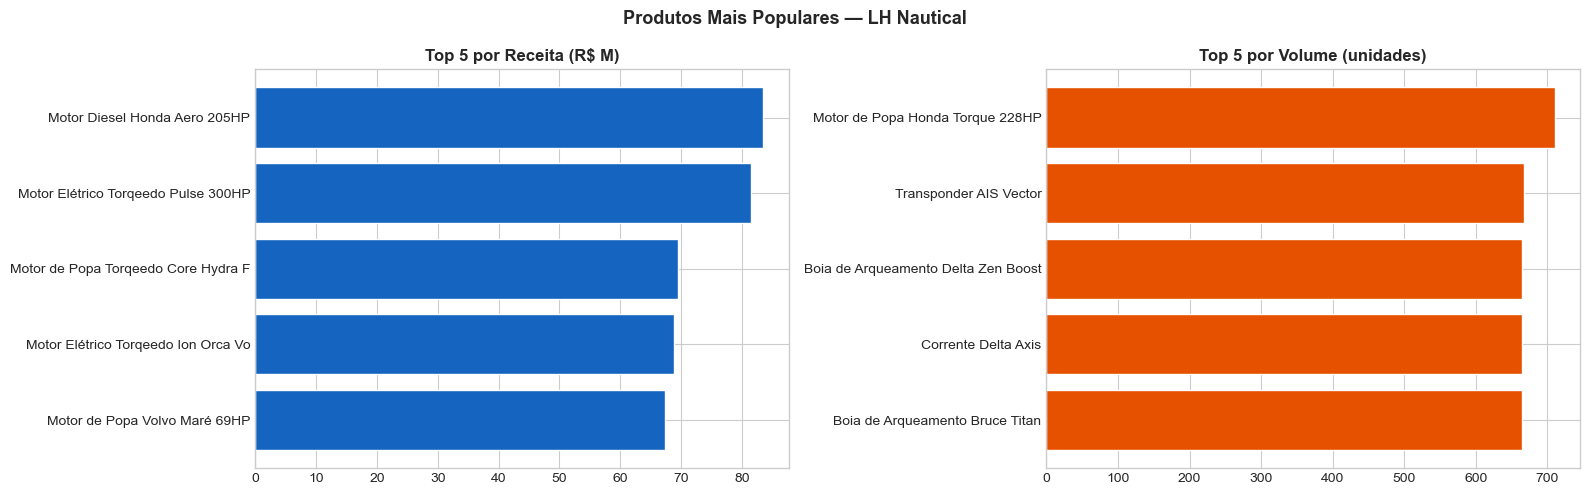

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top5_r = pop_receita.head(5)
axes[0].barh(top5_r['nome_produto'].str[:35], top5_r['receita_total'] / 1e6,
             color=AZUL_LH, edgecolor='white')
axes[0].set_title('Top 5 por Receita (R$ M)', fontweight='bold')
axes[0].invert_yaxis()

top5_v = pop_volume.head(5)
axes[1].barh(top5_v['nome_produto'].str[:35], top5_v['score_volume'],
             color=LARANJA_LH, edgecolor='white')
axes[1].set_title('Top 5 por Volume (unidades)', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Produtos Mais Populares — LH Nautical', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Produtos Relacionados

Para a página de produto: *"Clientes que compraram X também compraram..."*

In [4]:
# Top 3 produtos por receita como exemplos
top3_ids = fato.groupby('id_produto')['receita_liquida'].sum().nlargest(3).index.tolist()

for pid in top3_ids:
    nome_prod = dim_prod.loc[dim_prod['id_produto'] == pid, 'nome_produto'].values
    nome_str  = nome_prod[0] if len(nome_prod) > 0 else f'Produto {pid}'

    relacionados = produtos_relacionados(fato, produto_id=pid, n=5)
    if not relacionados.empty:
        relacionados = relacionados.merge(
            dim_prod[['id_produto','nome_produto','categoria']], on='id_produto'
        )
        print(f'\nClientes que compraram "{nome_str[:40]}" tambem compraram:')
        display(relacionados[['nome_produto','categoria','clientes_comuns','vezes_comprado']])
    else:
        print(f'\nProduto {pid}: sem dados suficientes para relacionamento')


Clientes que compraram "Motor Diesel Honda Aero 205HP" tambem compraram:


,nome_produto,categoria,clientes_comuns,vezes_comprado
0,Corrente Danforth Zenith Oceanic Torque,Ancoragem,34,61
1,Boia de Arqueamento Danforth Torque,Ancoragem,33,55
2,Radar Furuno Swift,Eletrônicos,32,63
3,Motor Diesel Tohatsu Evo Zenith 16HP,Propulsão,32,45
4,Rádio Lowrance Nitro Thrust Barracuda,Eletrônicos,32,53



Clientes que compraram "Motor Elétrico Torqeedo Pulse 300HP" tambem compraram:


,nome_produto,categoria,clientes_comuns,vezes_comprado
0,Âncora Delta Swift,Ancoragem,33,59
1,Piloto Automático Furuno Core Boost Flux,Eletrônicos,32,64
2,Motor Diesel Tohatsu Evo Zenith 16HP,Propulsão,32,45
3,GPS Furuno Swift Leviathan Poseidon,Eletrônicos,32,53
4,Transponder AIS Maré Magnum,Eletrônicos,31,54



Clientes que compraram "Motor de Popa Torqeedo Core Hydra Flux 1" tambem compraram:


,nome_produto,categoria,clientes_comuns,vezes_comprado
0,Âncora Delta Swift,Ancoragem,33,67
1,Cabo de Nylon Delta Force Magnum Leviathan,Ancoragem,33,65
2,Âncora Bruce Aqua,Ancoragem,32,57
3,Motor Diesel Tohatsu Evo Zenith 16HP,Propulsão,32,48
4,Motor de Popa Volvo Maré 69HP,Propulsão,32,60


---
## 3. Análise de Cesta (Market Basket Analysis)

Identifica **pares de produtos** mais comprados pelo mesmo cliente.
Útil para **kits promocionais** e **sugestões no checkout**.

In [5]:
cesta = analise_cesta_compras(fato, min_suporte=2, top_n=15)

if not cesta.empty:
    cesta = (
        cesta
        .merge(dim_prod[['id_produto','nome_produto']].rename(
            columns={'id_produto': 'produto_a', 'nome_produto': 'nome_a'}), on='produto_a')
        .merge(dim_prod[['id_produto','nome_produto']].rename(
            columns={'id_produto': 'produto_b', 'nome_produto': 'nome_b'}), on='produto_b')
    )

    print('Pares de produtos mais comprados juntos:')
    display(cesta[['nome_a','nome_b','clientes_comuns','suporte_pct']].head(10))
else:
    print('Volume insuficiente para MBA com suporte >= 2.')

Pares de produtos mais comprados juntos:


,nome_a,nome_b,clientes_comuns,suporte_pct
0,GPS Furuno Swift Leviathan Poseidon,Corrente Danforth Zenith Oceanic Torque,38,77.55
1,Âncora Delta Swift,Corrente Danforth Zenith Oceanic Torque,38,77.55
2,GPS Furuno Swift Leviathan Poseidon,Âncora Delta Swift,38,77.55
3,Motor Diesel Tohatsu Evo Zenith 16HP,Âncora Delta Swift,38,77.55
4,GPS Furuno Swift Leviathan Poseidon,Radar Furuno Swift,38,77.55
5,Radar Furuno Swift,Corrente Danforth Zenith Oceanic Torque,38,77.55
6,GPS Furuno Swift Leviathan Poseidon,Rádio Lowrance Nitro Thrust Barracuda,37,75.51
7,GPS Furuno Swift Leviathan Poseidon,Motor de Popa Honda Torque 228HP,37,75.51
8,Transponder AIS Maré Magnum,GPS Furuno Swift Leviathan Poseidon,37,75.51
9,Transponder AIS Maré Magnum,Corrente Danforth Zenith Oceanic Torque,37,75.51


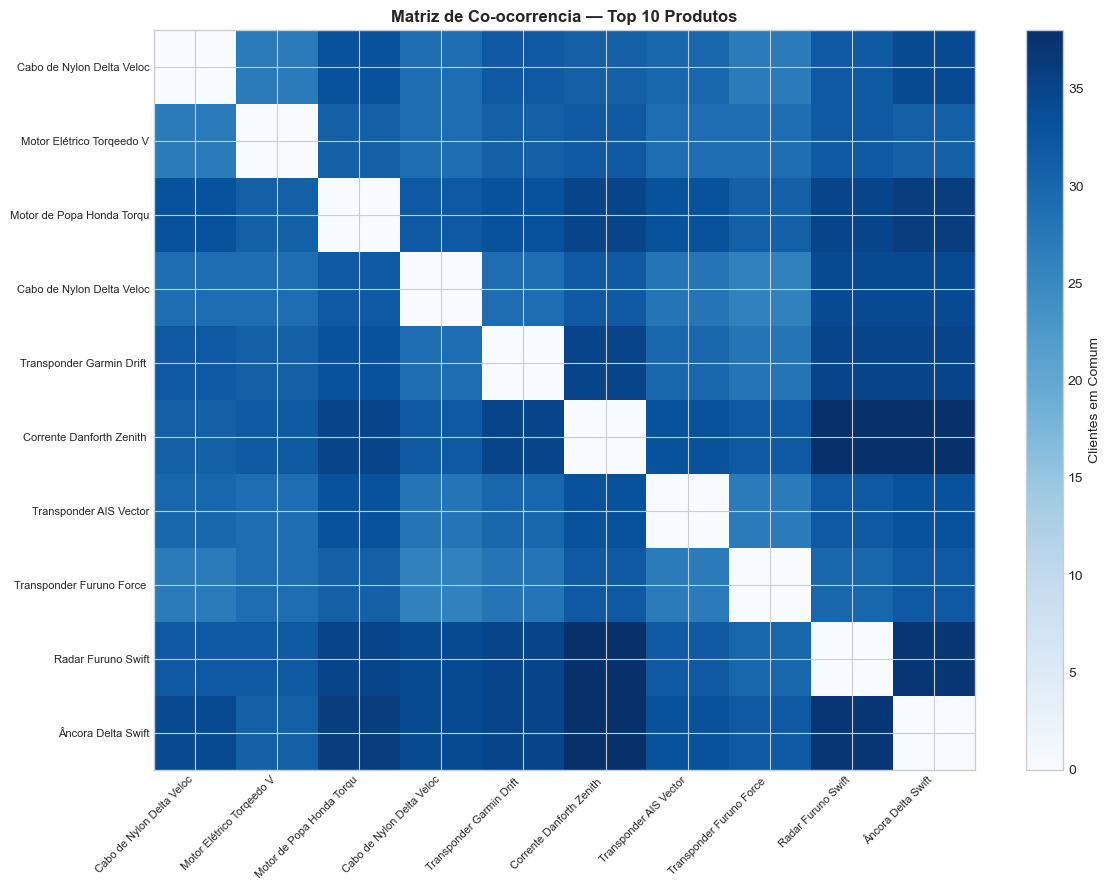

In [6]:
# Matriz de co-ocorrencia — Top 10 produtos
top_prods = fato['id_produto'].value_counts().head(10).index
pivot_bin = (
    fato.groupby(['id_cliente','id_produto'])['quantidade']
    .sum().unstack(fill_value=0)
    .reindex(columns=top_prods, fill_value=0)
)
pivot_bin = (pivot_bin > 0).astype(int)
co_matrix = pivot_bin.T.dot(pivot_bin)

# Rotulos curtos
nome_map  = dict(zip(dim_prod['id_produto'], dim_prod['nome_produto'].str[:25]))
rotulos   = [nome_map.get(i, str(i)) for i in co_matrix.index]
co_matrix.index   = rotulos
co_matrix.columns = rotulos
np.fill_diagonal(co_matrix.values, 0)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(co_matrix.values, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, label='Clientes em Comum')
ax.set_xticks(range(len(rotulos)))
ax.set_yticks(range(len(rotulos)))
ax.set_xticklabels(rotulos, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(rotulos, fontsize=8)
ax.set_title('Matriz de Co-ocorrencia — Top 10 Produtos', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Estratégias de Aplicação

### E-commerce
- **Pagina inicial:** Top 10 por receita (secao "Mais Vendidos")
- **Pagina do produto:** "Compre junto" baseado em co-ocorrencia
- **Checkout:** Sugestao do par mais comprado junto

### Para os 49 Clientes B2B
- **Gerente de conta:** Apresentar os produtos relacionados ao historico de cada cliente
- **Kits pre-montados:** Usar os pares mais frequentes para criar combos com desconto
- **Reativacao:** Sugerir produtos que o cliente ainda nao comprou mas tem alta co-ocorrencia

### Evolucao (com mais dados)
```
500+ clientes com 3+ compras:
  -> Filtro colaborativo usuario x usuario (scikit-surprise)
  -> Algoritmo Apriori completo (suporte, confianca, lift)
  -> Personalizacao por perfil de cliente
```

> **Projeto concluído!** Os dados estao prontos para importacao no Power BI
> atraves dos arquivos Parquet em `data/gold/`.